# NB06 — H3 Test: Porewater-Bias Signature

**Hypothesis**
- **H0**: BERDL's clay cohort reflects unbiased mixture of rock-attached and porewater organisms; SR-marker (dsrAB-aprAB) and IRB-marker (omcS / mtrC / mtrA) prevalences are at parity.
- **H1**: BERDL's clay cohort is biased toward Bagnoud (2016) porewater signature (SR-rich) rather than Mitzscherling (2023) rock-attached signature (IR-rich), because cultivable porewater organisms are over-represented.

**Mitzscherling 2023 reference frequencies** (16S amplicon abundance on rock-attached samples): SRB <0.2%, IRB 4.3–10.2%. We use a 2×2 Fisher's exact comparing observed cohort genome counts against these expected frequencies (treating expected as a generative null for prevalence).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

anchor = pd.read_parquet(DATA_DIR / 'genome_features.parquet')
baseline = pd.read_parquet(DATA_DIR / 'baseline_features.parquet')
all_features = pd.concat([anchor, baseline], ignore_index=True)
for c in ['checkm_completeness']:
    all_features[c] = pd.to_numeric(all_features[c], errors='coerce')
qc = all_features[all_features['checkm_completeness'] >= 80].copy()
print(f'qc cohort sizes: {qc["cohort_class"].value_counts().to_dict()}')

qc cohort sizes: {'soil_baseline': 140, 'anchor_shallow': 30, 'unclassified': 18, 'anchor_deep': 9, 'excluded': 2}


## 1. SR vs IR marker presence per cohort

In [2]:
qc['marker_class'] = 'neither'
qc.loc[qc['SR_complete'] & ~qc['IR_complete'], 'marker_class'] = 'SR_only'
qc.loc[~qc['SR_complete'] & qc['IR_complete'], 'marker_class'] = 'IR_only'
qc.loc[qc['SR_complete'] & qc['IR_complete'], 'marker_class'] = 'both'

tab = pd.crosstab(qc['cohort_class'], qc['marker_class']).reindex(
    ['anchor_deep','anchor_shallow','soil_baseline'])
tab_pct = tab.div(tab.sum(axis=1), axis=0).round(3)
print('=== counts ===')
print(tab)
print('\n=== fractions ===')
print(tab_pct)

=== counts ===
marker_class    IR_only  SR_only  both  neither
cohort_class                                   
anchor_deep           1        5     0        3
anchor_shallow       15        0     0       15
soil_baseline        29        4     1      106

=== fractions ===
marker_class    IR_only  SR_only   both  neither
cohort_class                                    
anchor_deep       0.111    0.556  0.000    0.333
anchor_shallow    0.500    0.000  0.000    0.500
soil_baseline     0.207    0.029  0.007    0.757


## 2. Direct test: SR vs IR ratio in anchor_deep vs Mitzscherling rock-attached null

Mitzscherling 2023 rock-attached: SRB ~0.2%, IRB ~7% (mean of 4.3–10.2%). For n=9 deep, expected SR ≈ 0, expected IR ≈ 1. Observed: SR=5, IR=1. Run binomial / Fisher comparing observed deep cohort to a hypothetical "Mitzscherling-like" rock-attached cohort of equal size.

In [3]:
# Build a hypothetical Mitzscherling rock-attached cohort matching anchor_deep size
n_deep = (qc['cohort_class'] == 'anchor_deep').sum()
exp_SR_rock = 0.002  # Mitzscherling rock-attached
exp_IR_rock = 0.07

obs_SR_deep = int(qc[(qc['cohort_class'] == 'anchor_deep') & qc['SR_complete']].shape[0])
obs_IR_deep = int(qc[(qc['cohort_class'] == 'anchor_deep') & qc['IR_complete']].shape[0])

# binomial test for SR enrichment vs Mitzscherling rock null
p_sr = stats.binomtest(obs_SR_deep, n_deep, exp_SR_rock, alternative='greater').pvalue
# binomial test for IR depletion vs Mitzscherling rock null
p_ir = stats.binomtest(obs_IR_deep, n_deep, exp_IR_rock, alternative='less').pvalue

h3_test_a = pd.DataFrame([
    dict(test='SR enrichment vs Mitzscherling rock-attached', n=n_deep, observed=obs_SR_deep,
         expected_freq=exp_SR_rock, p=p_sr),
    dict(test='IR depletion vs Mitzscherling rock-attached', n=n_deep, observed=obs_IR_deep,
         expected_freq=exp_IR_rock, p=p_ir),
])
h3_test_a

,test,n,observed,expected_freq,p
0,SR enrichment vs Mitzscherling rock-attached,9,5,0.002,4.005189e-12
1,IR depletion vs Mitzscherling rock-attached,9,1,0.070,8.729476e-01


## 3. SR:IR ratio comparison: anchor_deep vs anchor_shallow vs soil_baseline

Direct cohort-vs-cohort Fisher test on SR-vs-IR distribution.

In [4]:
rows = []
for grp_a, grp_b in [('anchor_deep','anchor_shallow'),
                     ('anchor_deep','soil_baseline'),
                     ('anchor_shallow','soil_baseline')]:
    for marker in ['SR_complete','IR_complete']:
        a = qc[qc['cohort_class'] == grp_a][marker]
        b = qc[qc['cohort_class'] == grp_b][marker]
        table = [[a.sum(), len(a) - a.sum()], [b.sum(), len(b) - b.sum()]]
        odds, p = stats.fisher_exact(table, alternative='two-sided')
        rows.append(dict(grp_a=grp_a, grp_b=grp_b, marker=marker,
                         n_a=len(a), pos_a=int(a.sum()),
                         n_b=len(b), pos_b=int(b.sum()),
                         odds_ratio=odds, p_value=p))
h3_test_b = pd.DataFrame(rows).round(4)
h3_test_b

,grp_a,grp_b,marker,n_a,pos_a,n_b,pos_b,odds_ratio,p_value
0,anchor_deep,anchor_shallow,SR_complete,9,5,30,0,inf,0.0002
1,anchor_deep,anchor_shallow,IR_complete,9,1,30,15,0.1250,0.0560
2,anchor_deep,soil_baseline,SR_complete,9,5,140,5,33.7500,0.0000
3,anchor_deep,soil_baseline,IR_complete,9,1,140,30,0.4583,0.6856
4,anchor_shallow,soil_baseline,SR_complete,30,0,140,5,0.0000,0.5876
5,anchor_shallow,soil_baseline,IR_complete,30,15,140,30,3.6667,0.0025


## 4. Visualization

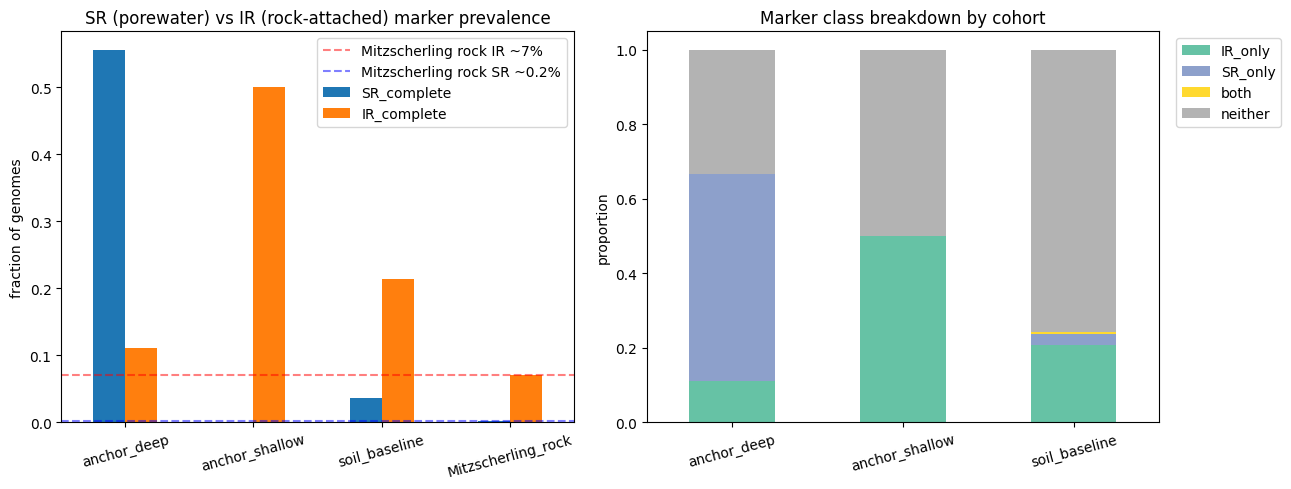

saved: ../figures/h3_porewater_vs_rock.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar of SR vs IR rate per cohort vs Mitzscherling rock-attached null
order = ['anchor_deep', 'anchor_shallow', 'soil_baseline']
rates = qc.groupby('cohort_class')[['SR_complete','IR_complete']].mean().reindex(order)
rates_with_null = pd.concat([rates, pd.DataFrame({'SR_complete':[0.002], 'IR_complete':[0.07]}, index=['Mitzscherling_rock'])])
rates_with_null.plot(kind='bar', ax=axes[0])
axes[0].set_title('SR (porewater) vs IR (rock-attached) marker prevalence')
axes[0].set_ylabel('fraction of genomes')
axes[0].axhline(0.07, color='red', linestyle='--', alpha=0.5, label='Mitzscherling rock IR ~7%')
axes[0].axhline(0.002, color='blue', linestyle='--', alpha=0.5, label='Mitzscherling rock SR ~0.2%')
axes[0].legend()
axes[0].set_xticklabels(order + ['Mitzscherling_rock'], rotation=15)
axes[0].set_xlabel('')

# Stacked bar of marker class
tab_pct.reindex(order).plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Marker class breakdown by cohort')
axes[1].set_ylabel('proportion')
axes[1].set_xticklabels(order, rotation=15)
axes[1].set_xlabel('')
axes[1].legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
out_fig = FIG_DIR / 'h3_porewater_vs_rock.png'
plt.savefig(out_fig, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved: {out_fig}')

In [6]:
h3_test_a.to_csv(DATA_DIR / 'h3_vs_mitzscherling.tsv', sep='\t', index=False)
h3_test_b.to_csv(DATA_DIR / 'h3_cohort_pairwise.tsv', sep='\t', index=False)
tab.to_csv(DATA_DIR / 'h3_marker_class_table.tsv', sep='\t')
print('saved h3_*.tsv')
print('\n=== summary ===')
print('Anchor_deep vs Mitzscherling rock-attached null:')
print(h3_test_a.round(4))
print('\nCohort pairwise:')
print(h3_test_b)

saved h3_*.tsv

=== summary ===
Anchor_deep vs Mitzscherling rock-attached null:
                                           test  n  observed  expected_freq  \
0  SR enrichment vs Mitzscherling rock-attached  9         5          0.002   
1   IR depletion vs Mitzscherling rock-attached  9         1          0.070   

        p  
0  0.0000  
1  0.8729  

Cohort pairwise:
            grp_a           grp_b       marker  n_a  pos_a  n_b  pos_b  \
0     anchor_deep  anchor_shallow  SR_complete    9      5   30      0   
1     anchor_deep  anchor_shallow  IR_complete    9      1   30     15   
2     anchor_deep   soil_baseline  SR_complete    9      5  140      5   
3     anchor_deep   soil_baseline  IR_complete    9      1  140     30   
4  anchor_shallow   soil_baseline  SR_complete   30      0  140      5   
5  anchor_shallow   soil_baseline  IR_complete   30     15  140     30   

   odds_ratio  p_value  
0         inf   0.0002  
1      0.1250   0.0560  
2     33.7500   0.0000  
3      0